In [14]:
import numpy as np
import pandas as pd
import torch

from scipy.optimize import minimize

In [15]:
from matplotlib import pyplot as plt
import seaborn as sns

In [16]:
n = 200
np.random.seed(10061988)

# Model Definition
n_grid = 300
x = np.linspace(0, 1, n_grid)

# Data
ic = np.nan
D = torch.load('dataExample.pt')

In [ ]:
D['ind']

In [18]:
for key, value in D.items():
    if type(value) == list:
        print('\n', key, "list", len(value))
        
    elif type(value) == dict:
        print('\n',key, "dict", value.keys())
        for k,v in value.items():
            try:
                print('\t', k, v.shape)
            except:
                print('\t', k, len(v))
                
for k, v in D['ind'].items():
    try:
        print(k, [ar.shape for ar in v])
    except:
        print(k, v)


 pop dict dict_keys(['t', 'mean', 'var'])
	 t (6,)
	 mean (6,)
	 var (6,)

 ind dict dict_keys(['tp', 'hist', 'size'])
	 tp 18
	 hist 18
	 size 18

 xsdt list 6

 csdt list 6

 dist dict dict_keys(['mean', 'var'])
	 mean torch.Size([6])
	 var torch.Size([6])
tp [(), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ()]
hist [(10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,), (10000,)]
size [10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000]


In [6]:
D['ind']['tp']

[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5]

In [110]:
options = {'alpha': 10, 'Aug_matrix': [], 'x_combined': []}

In [111]:
D['pop']

{'t': array([0, 1, 2, 3, 4, 5]),
 'mean': array([ 14806.34199907,  34160.69057224,  62176.66570209, 104999.13450001,
        167669.36988238, 264987.11883031]),
 'var': array([ 34671.36327279, 119138.76915183, 216067.65068624, 372200.01556752,
        240500.96688416, 239079.47251767])}

# x_combined and Aug_matrix

In [139]:
from functions import augment_cdf

In [140]:
D['csd_a'] = []
for it in range(6):  # 1 + len(D['pop']['t'])
    x_combined = np.union1d(x[:-1], D['xsdt'][it])
    D['csd_a'].append(
        augment_cdf(D['xsdt'][it], x_combined, D['csdt'][0].reshape(-1,1)))
    options['x_combined'].append(x_combined)

In [ ]:
for it in range(1, len(D['pop']['t'])):
    
    aug_M = []
    
    for ig in range(n_grid - 1):
        e_i = np.zeros((n_grid - 1,1))
        e_i[ig] = 1
        aug_M.append(  augment_cdf(x[:-1], options['x_combined'][it], e_i) ) # ???
    
    
    options['Aug_matrix'].append(np.hstack(aug_M))

In [1]:
from torchcubicspline import natural_cubic_spline_coeffs, NaturalCubicSpline

In [2]:
import torch

In [11]:
t = torch.linspace(0, 1, 4)
        # (2, 1) are batch dimensions. 7 is the time dimension
        # (of the same length as t). 3 is the channel dimension.
x = torch.rand(4,1)
coeffs = natural_cubic_spline_coeffs(t, x)
# coeffs is a tuple of tensors

# ...at this point you can save the coeffs, put them
# through PyTorch's Datasets and DataLoaders, etc...

spline = NaturalCubicSpline(coeffs)

In [12]:
t.shape
x.shape

torch.Size([4, 1])

# test functions

In [43]:
u_0, _, _ = functions.boundary_density_at(D, 0, x)

In [44]:
u_0.shape

(299,)

# test data loader

In [1]:
import reader
import functions
from importlib import reload
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [ ]:
reload(reader)

In [2]:
pt_path = 'dataExample.pt'
train_DS = reader.Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=300, n_repeat=10)
val_DS= reader.Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=600, n_repeat=1)

In [3]:
train_iter = iter(train_DS) 

In [4]:
s_col, t_col, s_all, t_b, u_b, mean, var = next(train_iter)

In [5]:
s_col.shape, t_col.shape, s_all.shape

(torch.Size([300, 1]), torch.Size([300, 1]), torch.Size([300]))

In [6]:
u_b[0].shape

torch.Size([6, 300])

In [24]:
(u_b[0]).sum(axis=1) /h_inv

tensor([ 14856.0540,  34160.6906,  62176.6871, 104999.1345, 167669.7199,
        264989.6211], dtype=torch.float64)

In [18]:
# Model Definition
n_grid = 300
grid = np.linspace(0, 1, n_grid)
h_inv = (1 / (grid[1] - grid[0]))

In [19]:
h_inv = (1 / (grid[1] - grid[0]))

In [20]:
(grid[1] - grid[0])

0.0033444816053511705

In [25]:
RN = pd.read_csv('./rawData/pseudodynamics_input_example_popsize.csv')

# Number of replicates for population size
n = RN.iloc[:, 3].values


mean_s = RN.iloc[:, 1].values
var_s =  / n

In [30]:
np.log(mean_s)

array([ 9.60281088, 10.43883086, 11.03773506, 11.56170739, 12.02974928,
       12.4874365 ])

In [32]:
np.log(np.square(RN.iloc[:, 2].values)) /2

array([6.72470082, 7.34188825, 7.63953955, 7.91145947, 7.69310583,
       7.69014179])

In [33]:
mean, var

((tensor([ 14806.3420,  34160.6906,  62176.6657, 104999.1345, 167669.3699,
          264987.1188], dtype=torch.float64),),
 tensor([ 34671.3633, 119138.7692, 216067.6507, 372200.0156, 240500.9669,
         239079.4725], dtype=torch.float64))

# training

In [5]:
torch.Tensor(600,1).uniform_(0,1)

tensor([[0.5660],
        [0.1426],
        [0.3115],
        [0.6620],
        [0.8713],
        [0.3320],
        [0.0105],
        [0.1655],
        [0.5958],
        [0.4878],
        [0.0640],
        [0.3019],
        [0.9637],
        [0.1955],
        [0.8360],
        [0.5560],
        [0.7045],
        [0.0118],
        [0.5896],
        [0.8505],
        [0.6249],
        [0.4561],
        [0.8166],
        [0.3143],
        [0.0734],
        [0.0414],
        [0.7367],
        [0.3832],
        [0.1532],
        [0.5936],
        [0.2091],
        [0.1269],
        [0.2899],
        [0.4675],
        [0.7294],
        [0.2725],
        [0.2057],
        [0.3625],
        [0.3031],
        [0.2490],
        [0.8555],
        [0.4182],
        [0.7425],
        [0.6072],
        [0.5808],
        [0.5247],
        [0.5710],
        [0.3951],
        [0.2352],
        [0.9400],
        [0.3993],
        [0.5776],
        [0.8086],
        [0.2749],
        [0.9966],
        [0

In [11]:
### Training and Fitting

iterations = 20000
previous_validation_loss = 99999

for epoch in range(iterations):
    
    optimizer.zero_grad() # to maket the gradients zero
    
    # Loss based on boundary conditions
    pt_x_bc = Variable(torch.from_numpy(x_bc).float(), requires_grad=False).to(device)
    pt_u_bc1 = Variable(torch.from_numpy(y_bc).float(), requires_grad=False).to(device)
    pt_t_bc1 = Variable(torch.from_numpy(t_bc0).float(), requires_grad=False).to(device)

    pt_t_bc0 = Variable(torch.from_numpy(t_bc0).float(), requires_grad=False).to(device)
    pt_u_bc0 = Variable(torch.from_numpy(u_bc).float(), requires_grad=False).to(device)
    
    net_bc_out0 = u_theta(pt_x_bc, pt_t_bc0) 
    mse_b0 = mse_cost_function(net_bc_out0, pt_u_bc0)    # loss B

    net_bc_out1 = u_theta(pt_x_bc, pt_t_bc1) 
    mse_b1 = mse_cost_function(net_bc_out1, pt_u_bc1)    # loss B
    
    # Loss based on PDE
    x_collocation = np.random.uniform(low=0.0, high=2.0, size=(500,1))
    t_collocation = np.random.uniform(low=0.0, high=1.0, size=(500,1))
    all_zeros = np.zeros((500,1))
    
    pt_x_collocation = Variable(torch.from_numpy(x_collocation).float(), requires_grad=True).to(device)
    pt_t_collocation = Variable(torch.from_numpy(t_collocation).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out = f(pt_x_collocation, pt_t_collocation, u_theta) # output of collocation points
    mse_f = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_b0 + mse_b1 + mse_f
    
    loss.backward()
    optimizer.step()
    
    with torch.autograd.no_grad():
        print(epoch, "Training Loss:", loss.data)

0 Training Loss: tensor(6.6451, device='cuda:0')
1 Training Loss: tensor(6.6231, device='cuda:0')
2 Training Loss: tensor(6.6013, device='cuda:0')
3 Training Loss: tensor(6.5796, device='cuda:0')
4 Training Loss: tensor(6.5579, device='cuda:0')
5 Training Loss: tensor(6.5365, device='cuda:0')
6 Training Loss: tensor(6.5151, device='cuda:0')
7 Training Loss: tensor(6.4938, device='cuda:0')
8 Training Loss: tensor(6.4728, device='cuda:0')
9 Training Loss: tensor(6.4519, device='cuda:0')
10 Training Loss: tensor(6.4308, device='cuda:0')
11 Training Loss: tensor(6.4103, device='cuda:0')
12 Training Loss: tensor(6.3896, device='cuda:0')
13 Training Loss: tensor(6.3691, device='cuda:0')
14 Training Loss: tensor(6.3489, device='cuda:0')
15 Training Loss: tensor(6.3286, device='cuda:0')
16 Training Loss: tensor(6.3086, device='cuda:0')
17 Training Loss: tensor(6.2886, device='cuda:0')
18 Training Loss: tensor(6.2688, device='cuda:0')
19 Training Loss: tensor(6.2490, device='cuda:0')
20 Trainin

# test cubic spine function

In [50]:
from functions import h_poly, spine_fun, interp

In [52]:
import torch
import numpy as np

In [54]:
from models import CubicSpine

In [35]:
import matplotlib.pyplot as plt

In [44]:
x = torch.from_numpy(np.linspace(0,1,11))

y = torch.from_numpy(np.random.random(11,))
y = torch.nn.parameter.Parameter(y, requires_grad=True)

xs = torch.from_numpy(np.random.random(100,))

In [45]:
idxs = torch.searchsorted(x[1:], xs)
dx = (x[idxs + 1] - x[idxs])
t = (xs - x[idxs]) / dx
hh = h_poly(t)

In [46]:
torch.arange(4)

tensor([0, 1, 2, 3])

In [47]:
tt = t[None, :]**torch.arange(4, device=t.device)[:, None]
dx = x[1:] - x[:-1]

In [48]:
interp_v = interp(x, y, xs)

In [49]:
torch.autograd.grad(interp_v.sum(), y, retain_graph=True)[0]

tensor([ 5.8978, 10.3565, 10.7216,  6.2749,  7.9628, 12.6259, 15.1460,  7.5835,
         6.1602, 12.8866,  4.3842], dtype=torch.float64)

In [92]:
x = torch.from_numpy(np.linspace(0,1,11))
D_fn = CubicSpine(x)

In [93]:
xs = np.arange(0,1,0.005)
ys = D_fn(torch.from_numpy(xs), torch.Tensor([0]))

In [94]:
ys = ys.detach().cpu().numpy()

In [95]:
knot_x = D_fn.x.detach().cpu().numpy()
knot_y = D_fn.y.detach().cpu().numpy()

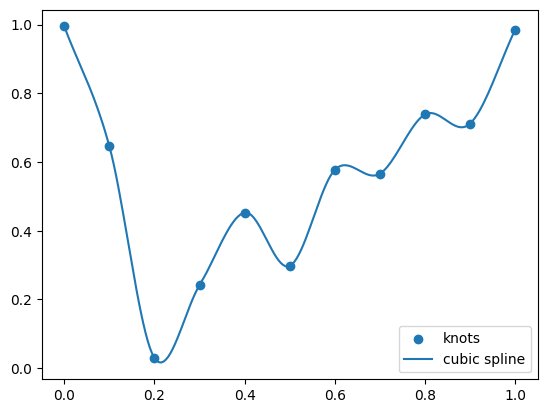

In [99]:
plt.scatter(knot_x, knot_y, label='knots')
plt.plot(xs, ys, label='cubic spline')
plt.legend()